# 🚀 PROJECT: THE MRIDANSH
## CENTRAL ENGINE: AETHER-MRID1607X
## Multi-Domain Soil Intelligence Engine (Agronomy & Geotechnical Stability)
**Division:** RS-SDA Division | JCC Campus 2  
**Core Framework:** Ensemble Kalman Filter (EnKF) Data Assimilation Engine  
**Operational Target:** Unified Sequential State Estimation & Error Covariance Propagation.

---

# 🛰️ Notebook 06: Sequential Soil-State Estimation (EnKF Assimilation)
**Sprint Phase:** Day 1 / 18-Day Scientific Audit & Validation Mission  
**Execution Objective:** Integrate Physics/ConvLSTM prior predictions with satellite observations via dynamic Ensemble Kalman Filtering to derive optimal posterior soil states and state covariance matrices.

### 🧮 Mathematical Mechanics: Ensemble Kalman Filter (EnKF)

Given state ensemble matrix $\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N] \in \mathbb{R}^{n \times N}$ containing $N$ ensemble members:

1. **State Vector Components:**
   $$\mathbf{x} = \begin{bmatrix} \theta_{\text{root}} \\ \rho_b \\ K_{\text{sat}} \\ \text{SOC} \end{bmatrix} \quad \begin{begin}{aligned} &\text{Root-zone Soil Moisture } [m^3/m^3] \\ &\text{Soil Bulk Density } [g/cm^3] \\ &\text{Hydraulic Conductivity } [cm/hr] \\ &\text{Soil Organic Carbon } [\%] \end{aligned}$$

2. **Ensemble Mean & Anomalies:**
   $$\bar{\mathbf{x}} = \frac{1}{N} \sum_{i=1}^N \mathbf{x}_i, \quad \mathbf{A} = \mathbf{X} - \bar{\mathbf{x}}\mathbf{1}^T$$

3. **Prior Error Covariance Estimation:**
   $$\mathbf{P}^f = \frac{1}{N-1} \mathbf{A} \mathbf{A}^T$$

4. **Kalman Gain Computation:**
   $$\mathbf{K} = \mathbf{P}^f \mathbf{H}^T \left( \mathbf{H} \mathbf{P}^f \mathbf{H}^T + \mathbf{R} \right)^{-1}$$

5. **Perturbed Measurement & Posterior State Update:**
   $$\mathbf{y}_i = \mathbf{y} + \boldsymbol{\epsilon}_i, \quad \boldsymbol{\epsilon}_i \sim \mathcal{N}(\mathbf{0}, \mathbf{R})$$
   $$\mathbf{x}_i^a = \mathbf{x}_i^f + \mathbf{K} \left( \mathbf{y}_i - \mathbf{H}\mathbf{x}_i^f \right)$$

In [11]:
import sys
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Inline Dark Theme Styling
%matplotlib inline
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['axes.edgecolor'] = '#00FFCC'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.color'] = '#1A3344'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

# Hardware and Reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(1607)
torch.manual_seed(1607)

print(f"⚡ [MRIDANSH-EnKF] Data Assimilation Engine Active on: {device}")

⚡ [MRIDANSH-EnKF] Data Assimilation Engine Active on: cuda


### 🌾 Step 1: Defining Target State Vector Parameters & Physical Bounds
Setting nominal reference values, physically acceptable bounds, and dynamic perturbation limits for state assimilation.

In [12]:
STATE_VARIABLES = {
    'theta_root': {'mean': 0.28, 'std': 0.04, 'min': 0.05, 'max': 0.45, 'unit': 'm³/m³', 'name': 'Root-Zone Moisture'},
    'bulk_density': {'mean': 1.35, 'std': 0.08, 'min': 1.00, 'max': 1.80, 'unit': 'g/cm³', 'name': 'Bulk Density'},
    'K_sat': {'mean': 2.50, 'std': 0.60, 'min': 0.01, 'max': 10.0, 'unit': 'cm/hr', 'name': 'Hydraulic Conductivity'},
    'SOC': {'mean': 1.20, 'std': 0.25, 'min': 0.10, 'max': 4.00, 'unit': '%', 'name': 'Soil Organic Carbon'}
}

STATE_NAMES = list(STATE_VARIABLES.keys())
NUM_STATES = len(STATE_NAMES)

print("=========================================================")
print("  🌾 MRIDANSH TARGET SOIL STATE VECTOR MATRIX            ")
print("=========================================================")
for var, meta in STATE_VARIABLES.items():
    print(f"• {meta['name']:<25} ({var}) : Nominal {meta['mean']:.2f} ± {meta['std']:.2f} {meta['unit']}")
print("=========================================================")

  🌾 MRIDANSH TARGET SOIL STATE VECTOR MATRIX            
• Root-Zone Moisture        (theta_root) : Nominal 0.28 ± 0.04 m³/m³
• Bulk Density              (bulk_density) : Nominal 1.35 ± 0.08 g/cm³
• Hydraulic Conductivity    (K_sat) : Nominal 2.50 ± 0.60 cm/hr
• Soil Organic Carbon       (SOC) : Nominal 1.20 ± 0.25 %


### 🎲 Step 2: Generating Synthetically Correlated Prior State Ensemble
Generating an ensemble matrix $\mathbf{X}^f \in \mathbb{R}^{4 \times 50}$ with physical cross-variable correlations (e.g., negative correlation between Bulk Density and Organic Carbon).

In [13]:
def generate_prior_ensemble(num_members = 50):
    """Generates prior state ensemble matrix X_prior with realistic cross-variable correlations."""
    means = np.array([STATE_VARIABLES[var]['mean'] for var in STATE_NAMES])
    stds = np.array([STATE_VARIABLES[var]['std'] for var in STATE_NAMES])

    # Define physical correlation matrix
    corr_matrix = np.array([
        [ 1.00, -0.30,  0.40,  0.20],     # Theta root
        [-0.30,  1.00, -0.50, -0.65],     # bulk_density
        [ 0.40, -0.50,  1.00,  0.35],     # K_sat
        [ 0.20, -0.65,  0.35,  1.00]      # SOC
    ])

    # Compute Covariance Matrix: Sigma = D * R * D
    D = np.diag(stds)
    cov_matrix = D @ corr_matrix @ D

    # Sample multivariate normal distribution
    ensemble = np.random.multivariate_normal(means, cov_matrix, size = num_members).T

    # Enforce physical clipping boundaries
    for i, var in enumerate(STATE_NAMES):
        ensemble[i, :] = np.clip(ensemble[i, :], STATE_VARIABLES[var]['min'], STATE_VARIABLES[var]['max'])

    return ensemble, cov_matrix

X_prior, P_prior_theoretical = generate_prior_ensemble(num_members = 50)

print(f"✅ Prior Ensemble Generated: Matrix Shape {X_prior.shape}")
print(f"   • Ensemble Mean Theta : {X_prior[0, :].mean():.4f} m³/m³")
print(f"   • Ensemble Std Theta  : {X_prior[0, :].std():.4f} m³/m³")

✅ Prior Ensemble Generated: Matrix Shape (4, 50)
   • Ensemble Mean Theta : 0.2831 m³/m³
   • Ensemble Std Theta  : 0.0431 m³/m³


### 📡 Step 3: Formulating Observation Matrix H and Noise Covariance R
Mapping the state space to observational satellite measurements (Sentinel-1 SAR surface moisture & SAR-derived roughness metrics).

In [14]:
def run_enkf_update(X_prior, obs_vector, obs_cov, H_operator):
    """Executes Ensemble Kalman Filter update step on prior state ensemble."""
    num_states, num_members = X_prior.shape
    num_obs = len(obs_vector)

    # 1. Ensemble Mean and Anomalies
    x_mean_prior = np.mean(X_prior, axis = 1, keepdims = True)
    A_prior = X_prior - x_mean_prior

    # 2. Prior Covariance Matrix p_f
    P_f = (A_prior @ A_prior.T) / (num_members - 1)

    # 3. Innovation Covariance S = H * P_f * H^T + R
    S = H_operator @ P_f @ H_operator.T + obs_cov

    # 4. Kalman Gain K = P_f * H^T * inv(S)
    K = P_f @ H_operator.T @ np.linalg.inv(S)

    # 5. Perturb Observations: Y = y + noise
    obs_noise = np.random.multivariate_normal(np.zeros(num_obs), obs_cov, size = num_members).T
    Y_perturbed = obs_vector.reshape(-1, 1) + obs_noise

    # 6. Ensemble State Update: X_post = X_prior + K * (Y - H * X_prior)
    innovation = Y_perturbed - (H_operator @ X_prior)
    X_posterior = X_prior + (K @ innovation)

    # 7. Posterior Covariance P_a
    x_mean_post = np.mean(X_posterior, axis = 1, keepdims = True)
    A_post = X_posterior - x_mean_post
    P_a = (A_post @ A_post.T) / (num_members - 1)

    return X_posterior, P_f, P_a, K, innovation

# Surface Moisture Observation (Sentinel-1 SAR observation target)
obs_val = np.array([0.34])                   # Direct surface observation showing wetter ground
R_obs = np.array([[0.0009]])                 # Observation variance (std = 0.03 m³/m³)
H_mat = np.array([[1.0, 0.0, 0.0, 0.0]])     # Observes theta_root directly

X_post, P_f, P_a, K_gain, innovation = run_enkf_update(X_prior, obs_val, R_obs, H_mat)

print("=========================================================")
print("  ⚡ EnKF SEQUENTIAL ASSIMILATION COMPLETED             ")
print("=========================================================")
print(f"• Observation Vector (y)    : {obs_val[0]:.4f} m³/m³")
print(f"• Prior Theta Mean          : {X_prior[0, :].mean():.4f} m³/m³ (Std: {X_prior[0, :].std():.4f})")
print(f"• Posterior Theta Mean      : {X_post[0, :].mean():.4f} m³/m³ (Std: {X_post[0, :].std():.4f})")
print(f"• Kalman Gain on Theta      : {K_gain[0, 0]:.4f}")
print(f"• Kalman Gain on Density    : {K_gain[1, 0]:.4f}")
print("=========================================================")

  ⚡ EnKF SEQUENTIAL ASSIMILATION COMPLETED             
• Observation Vector (y)    : 0.3400 m³/m³
• Prior Theta Mean          : 0.2831 m³/m³ (Std: 0.0431)
• Posterior Theta Mean      : 0.3259 m³/m³ (Std: 0.0215)
• Kalman Gain on Theta      : 0.6781
• Kalman Gain on Density    : -0.4338


### PLot - 1: Prior vs Posterior Ensemble Distributions

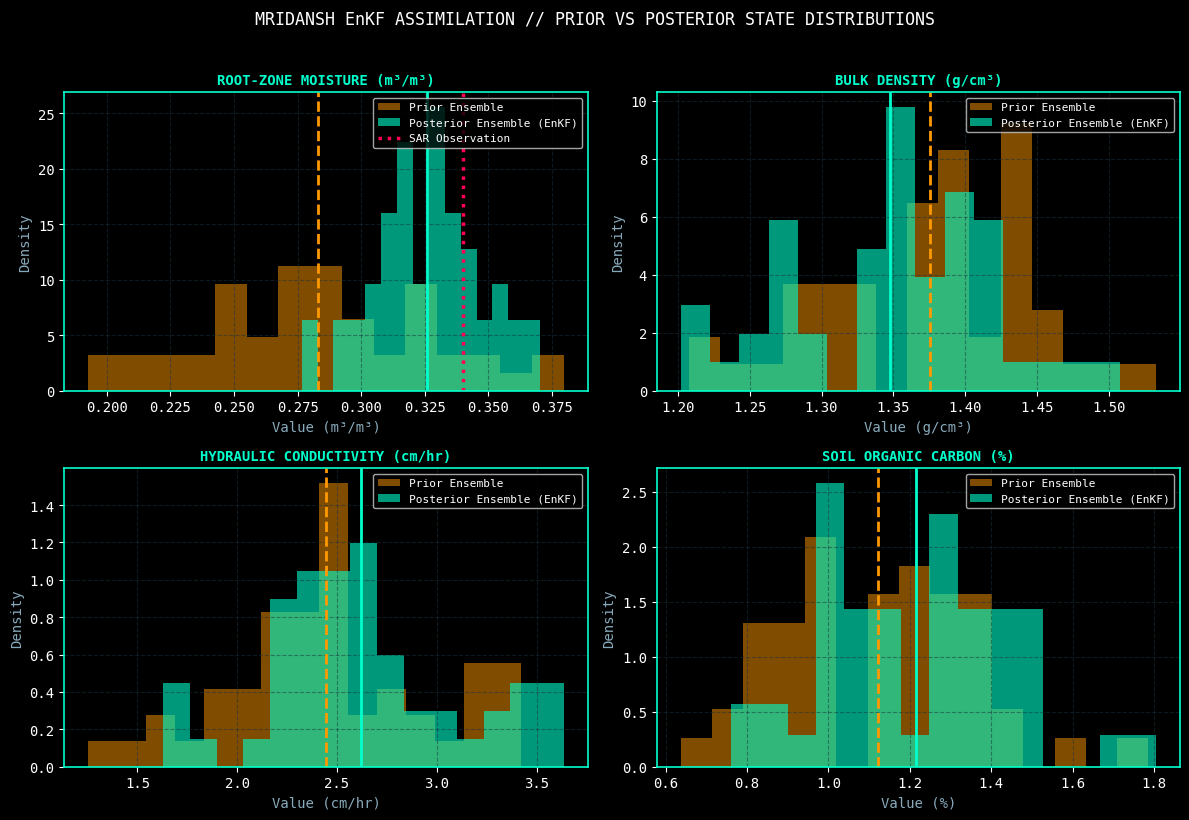

In [15]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

colors_prior = '#FF9900'
colors_post = '#00FFCC'

for i, var in enumerate(STATE_NAMES):
    ax = axes[i]
    meta = STATE_VARIABLES[var]

    # Histogram
    ax.hist(X_prior[i, :], bins = 15, alpha = 0.5, color = colors_prior, label='Prior Ensemble', density=True)
    ax.hist(X_post[i, :], bins = 15, alpha = 0.6, color = colors_post, label='Posterior Ensemble (EnKF)', density=True)

    # Vertical Mean Lines
    ax.axvline(X_prior[i, :].mean(), color = colors_prior, linestyle = '--', linewidth = 2)
    ax.axvline(X_post[i, :].mean(), color = colors_post, linestyle = '-', linewidth = 2)

    if i == 0:
        ax.axvline(obs_val[0], color = '#FF0055', linestyle = ':', linewidth = 2.5, label = 'SAR Observation')

    ax.set_title(f"{meta['name'].upper()} ({meta['unit']})", fontsize=10, color='#00FFCC', fontweight='bold')
    ax.set_xlabel(f"Value ({meta['unit']})", color='#88AABB')
    ax.set_ylabel("Density", color='#88AABB')
    ax.grid(True)
    ax.legend(loc = 'upper right', fontsize = 8)

plt.suptitle("MRIDANSH EnKF ASSIMILATION // PRIOR VS POSTERIOR STATE DISTRIBUTIONS", fontsize=12, color='white', y=1.02)
plt.tight_layout()
plt.show()